# Importing required libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Loading the model

In [14]:
data = pd.read_csv("high_popularity_spotify_data.csv")
data.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


# Encoding

In [15]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])
data    



,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,267,1229,172,20,371,327,371,512,1,53,...,0,143,0,6,1090,697,567,32,0,36
1,187,424,382,20,156,322,285,119,2,107,...,619,1169,1,2,685,618,1232,32,0,36
2,472,477,204,20,1091,364,229,367,2,116,...,0,106,1,1,268,627,1408,32,0,36
3,567,535,311,20,1113,491,583,806,2,329,...,0,669,0,0,210,515,299,32,0,36
4,449,1180,410,20,1032,527,694,762,2,611,...,0,362,0,0,292,310,1110,32,0,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,125,788,220,17,389,307,505,530,3,357,...,169,836,0,10,435,830,403,5,0,3
1682,393,431,348,17,316,315,368,692,2,473,...,646,848,0,3,418,767,364,5,0,3
1683,473,318,360,17,901,134,432,244,2,471,...,0,1065,0,6,506,603,1425,5,0,3
1684,314,104,123,17,1033,97,206,345,2,664,...,0,1090,1,1,465,700,963,5,0,3


# Dropping the Columns

In [16]:
X =data.drop(columns='track_popularity')
Y= data['track_popularity']

# Splitting

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2)

# Loading the model

In [18]:
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

# Predictions

In [19]:
y_pred = model.predict(x_test)
MSE = root_mean_squared_error(y_test , y_pred)
print(f" Predictions are :: {y_pred}")
print(f" Error is :: {MSE}")

 Predictions are :: [11.4168025   9.57911285 10.22838174  6.84406453  9.13578924  3.14396679
 11.58011234 10.57592055  4.51164521  5.79583842 11.9782036   9.81245048
  0.88719897  4.96295807  8.72901649  6.91501893  4.68454188  7.51520957
  6.59306824  6.93409351 11.46763288  8.54365896 11.03203983  4.52244695
 11.34839678  7.97401523 10.62384952  9.58182919 10.28770591  7.89380715
  8.34309484  7.30879165 10.91056895  7.73215393  9.67633595  6.62283111
  3.87607719 10.11430392  7.12094024  6.40734942 12.20123192  8.62448439
  8.35323326  9.15829512  8.13296751  3.94742551 10.55357024  5.35883794
 11.35969316  5.99814425  8.68024174  7.28671936  6.26539681  8.46761579
  7.34225861  7.64228132  7.5503682   5.8940796   8.72192685  9.14898354
  1.88815801  1.86442076  8.92880111  2.43915724 11.79165305  5.67419176
 10.37620177  5.80739711  9.24541368  7.56535574 11.01313044  3.38335694
  6.59649629 11.80243952  7.45258279  9.35958837  6.38163028  4.24192829
  5.42762032  6.58015864  8.624

# Plotting

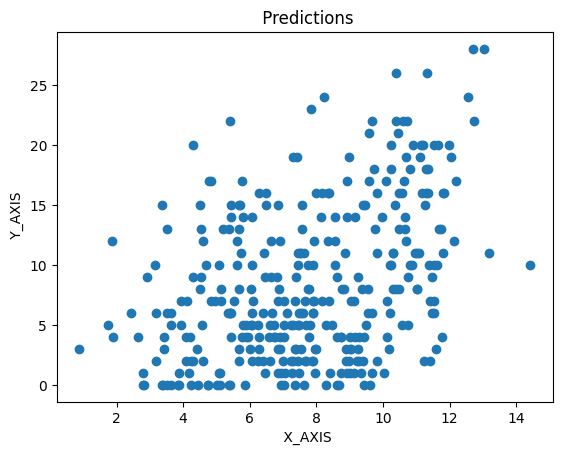

In [20]:
plt.scatter(y_pred , y_test)
plt.xlabel(" X_AXIS")
plt.ylabel(" Y_AXIS")
plt.title(" Predictions")
plt.show()